In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [28]:
bus = pd.read_csv("bus.csv",low_memory=False)
weather = pd.read_csv("weather.csv")


In [29]:
weather = weather.rename(columns={
    'temperature_2m (°C)': 'temperature',
    'precipitation (mm)': 'precipitation',
    'rain (mm)': 'rain'
})


In [30]:
bus['Occurred_On'] = pd.to_datetime(bus['Occurred_On'], errors='coerce')
weather['time'] = pd.to_datetime(weather['time'], errors='coerce')

bus = bus.dropna(subset=['Occurred_On'])
weather = weather.dropna(subset=['time'])


In [32]:
bus['How_Long_Delayed'] = pd.to_numeric(
    bus['How_Long_Delayed'], errors='coerce'
)

bus = bus.dropna(subset=['How_Long_Delayed'])
bus = bus[bus['How_Long_Delayed'] >= 0]


bus = bus[bus['How_Long_Delayed'] <= 180]  # max 3 hours


In [33]:
bus['hour'] = bus['Occurred_On'].dt.hour
bus['weekday'] = bus['Occurred_On'].dt.weekday


In [34]:
weather = weather[['time', 'temperature', 'precipitation', 'rain']]
weather = weather.fillna(0)


In [35]:
bus = bus.sort_values('Occurred_On')
weather = weather.sort_values('time')


In [36]:
merged = pd.merge_asof(
    bus,
    weather,
    left_on='Occurred_On',
    right_on='time',
    direction='nearest'
)


In [49]:
merged['is_peak_hour'] = np.where(
    (merged['hour'].between(7,10)) | (merged['hour'].between(16,19)),
    1, 0
)

merged['is_raining'] = np.where(merged['rain'] > 0, 1, 0)

merged['severe_delay'] = np.where(
    merged['How_Long_Delayed'] >= 45, 1, 0
)


In [50]:
features = [
    'hour',
    'weekday',
    'is_weekend',
    'temperature',
    'rain',
    'is_raining',
    'is_peak_hour'
]


In [51]:
merged['is_weekend'] = np.where(merged['weekday'] >= 5, 1, 0)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [52]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))


Logistic Regression Accuracy: 0.5545816733067729
              precision    recall  f1-score   support

           0       0.77      0.58      0.66       938
           1       0.28      0.49      0.36       317

    accuracy                           0.55      1255
   macro avg       0.53      0.53      0.51      1255
weighted avg       0.65      0.55      0.58      1255



In [55]:
merged['severe_delay'] = np.where(
    merged['How_Long_Delayed'] >= 45, 1, 0
)

merged['is_weekend'] = np.where(merged['weekday'] >= 5, 1, 0)

features = [
    'hour',
    'weekday',
    'is_weekend',
    'temperature',
    'rain',
    'is_raining',
    'is_peak_hour'
]

X = merged[features]
y = merged['severe_delay']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.7896414342629482
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1165
           1       0.12      0.29      0.16        90

    accuracy                           0.79      1255
   macro avg       0.53      0.56      0.52      1255
weighted avg       0.88      0.79      0.83      1255



In [56]:
from sklearn.metrics import accuracy_score

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))


Train Accuracy: 0.8220406536468713
Test Accuracy : 0.7896414342629482


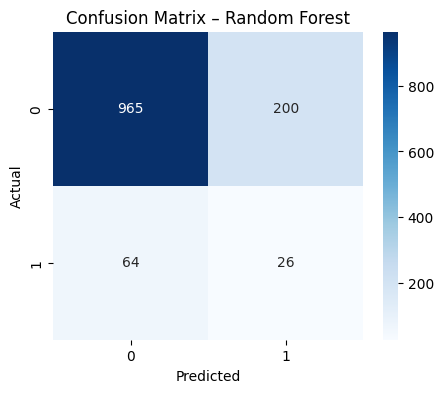

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()


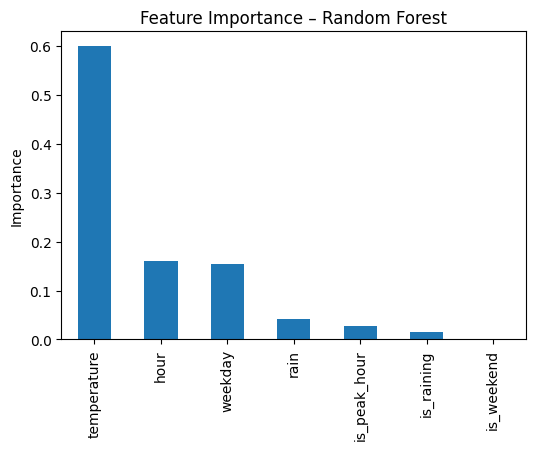

In [58]:
import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind='bar')
plt.title("Feature Importance – Random Forest")
plt.ylabel("Importance")
plt.show()


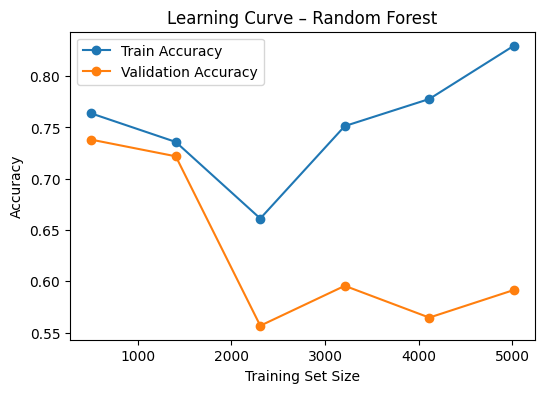

In [59]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, 'o-', label='Train Accuracy')
plt.plot(train_sizes, test_mean, 'o-', label='Validation Accuracy')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Random Forest")
plt.legend()
plt.show()
